In [2]:
import os
import pandas as pd
from matplotlib import pyplot as plt
from scipy.signal import savgol_filter
from pathlib import Path



In [2]:
# Import the leaf_eucalyptus.txt as a base, where I only substitute the values
base = pd.read_csv("D:/Andreas/Databases/leaf_eucalyptus.txt", sep="\t")

base.head()

# Getting the wavelengths from one of the source reflectances to get the correct window
wavelengths = pd.read_csv("C:/Users/Andreas/Documents/Merged_Data/Forward_Reflectance.csv", sep=",")
wavelengths.head()
#base.head()


,Wavelength,S129,S132,S133,S136,S138,S142,S143,S145,S148,...,S304,S306,S311,S315,S370,S371,S374,S40,S41,S60
0,400,0.043086,0.043143,0.043090,0.043112,0.043109,0.043561,0.043199,0.043137,0.043117,...,0.043094,0.043119,0.043257,0.043183,0.043109,0.043110,0.043310,0.043528,0.043127,0.043154
1,401,0.043086,0.043143,0.043090,0.043111,0.043109,0.043567,0.043201,0.043133,0.043116,...,0.043094,0.043119,0.043257,0.043183,0.043108,0.043111,0.043300,0.043519,0.043126,0.043151
2,402,0.043087,0.043143,0.043090,0.043111,0.043109,0.043573,0.043202,0.043130,0.043115,...,0.043093,0.043120,0.043258,0.043183,0.043107,0.043111,0.043291,0.043512,0.043125,0.043147
3,403,0.043087,0.043144,0.043090,0.043111,0.043110,0.043584,0.043205,0.043127,0.043114,...,0.043093,0.043121,0.043260,0.043184,0.043106,0.043113,0.043286,0.043509,0.043124,0.043145
4,404,0.043088,0.043146,0.043091,0.043112,0.043111,0.043603,0.043211,0.043126,0.043115,...,0.043093,0.043123,0.043266,0.043188,0.043106,0.043115,0.043285,0.043513,0.043125,0.043145


In [104]:
# Overwriting the wavelengths from the base file and changing the wavelengths to mikrometers for Dart
base = base.reindex(range(len(wavelengths)))

base["wavelength"] = wavelengths["Wavelength"] / 1000

print(base["wavelength"].head())
print(base["wavelength"].tail())


0    0.400
1    0.401
2    0.402
3    0.403
4    0.404
Name: wavelength, dtype: float64
2096    2.496
2097    2.497
2098    2.498
2099    2.499
2100    2.500
Name: wavelength, dtype: float64


In [105]:
# Read the Reflectance and Transmittance files for usage for every Species except Acacia
reflectance = pd.read_csv("C:/Users/Andreas/Documents/Merged_Data/Reflectance_merged.txt", sep="\t")
diffuse_transmittance = pd.read_csv("C:/Users/Andreas/Documents/Merged_Data/merged_scaled_transmittance_T.txt", sep="\t")
reflectance["wavelength"] = reflectance["wavelength"] / 1000
diffuse_transmittance["wavelength"] = diffuse_transmittance["wavelength"] / 1000


# Definition of Sample Lists and only taking the good quality samples

In [106]:
# Loading the good quality sample names
results_filtered_N_TT = pd.read_csv("C:/Users/Andreas/Documents/Merged_Data/results_filtered_N_TT.csv")

#Site 1R
samples_prosopis_s1r = [
    "S103", "S104", "S105", "S106",
    "S107", "S108", "S109", "S110",
    "S111", "S112", "S113", "S114",
    "S115", "S116", "S117", "S118",
    "S119", "S120", "S121", "S122"
]

samples_prosopis_s1r = [
    sample for sample in samples_prosopis_s1r
    if sample in results_filtered_N_TT["Sample"].values
]
#Site 3
samples_prosopis_s3 = ["S83", "S84", "S85", "S86", "S87", "S88", "S89", "S90", "S89.R", "S91", "S92", "S93", "S94", "S95", "S96", "S97", "S98", "S99", "S100", "S101", "S102"]
samples_fruticosa_s3 = ["S73", "S74", "S75", "S76", "S77", "S78", "S79", "S80", "S81", "S82"]

samples_fruticosa_s3 = [
    sample for sample in samples_fruticosa_s3
    if sample in results_filtered_N_TT["Sample"].values
]
samples_prosopis_s3 = [
    sample for sample in samples_prosopis_s3
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 10
samples_prosopis_s10 = [
    "S1", "S2", "S3", "S4",
    "S5", "S6", "S7", "S8",
    "S9", "S10", "S11", "S12",
    "S13", "S14", "S15", "S16",
    "S17", "S18"
]

samples_prosopis_s10 = [
    sample for sample in samples_prosopis_s10
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 11
samples_prosopis_s11 = [
    "S378",
    "S379",
    "S380",
    "S381",
    "S382",
    "S383",
    "S384",
    "S385",
    "S386",
    "S387"
]

samples_prosopis_s11 = [
    sample for sample in samples_prosopis_s11
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 14R
samples_prosopis_s14r = [
    "S1", "S2", "S3", "S4",
    "S5", "S6", "S7", "S8",
    "S9", "S10", "S11", "S12",
    "S13", "S14", "S15", "S16",
    "S17", "S18"
]

samples_prosopis_s14r = [
    sample for sample in samples_prosopis_s14r
    if sample in results_filtered_N_TT["Sample"].values
]

samples_balanite_aegyptica_s14r = [
    "S171", "S172", "S173", "S174"
]

samples_balanite_aegyptica_s14r = [
    sample for sample in samples_balanite_aegyptica_s14r
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 15
samples_prosopis_s15 = [
    "S326",
    "S327",
    "S328",
    "S329",
    "S330",
    "S331",
    "S332",
    "S333",
    "S334",
    "S335"
]

samples_prosopis_s15 = [
    sample for sample in samples_prosopis_s15
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 15
samples_ficus_s15 = [
    "S336",
    "S337",
    "S338",
    "S339",
    "S340",
    "S341",
    "S342",
    "S343",
    "S344",
    "S345",
    "S346",
    "S347",
    "S348",
    "S349",
    "S350",
    "S351"
]

samples_ficus_s15 = [
    sample for sample in samples_ficus_s15
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 15
samples_Parthenium_s15 = [
    "S352",
    "S353",
    "S354",
    "S355",
    "S356"
]

samples_Parthenium_s15 = [
    sample for sample in samples_Parthenium_s15
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 17R
samples_prosopis_s17r = [
    "S206", "S207", "S208", "S209",
    "S210", "S211", "S212", "S213",
    "S214", "S215", "S216", "S217",
    "S218", "S219"
]

samples_prosopis_s17r = [
    sample for sample in samples_prosopis_s17r
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 18
samples_prosopis_s18 = [
    "S191", "S192", "S193", "S194",
    "S195", "S196", "S197", "S198",
    "S199", "S200"
]

samples_prosopis_s18 = [
    sample for sample in samples_prosopis_s18
    if sample in results_filtered_N_TT["Sample"].values
]

samples_fruticosa_s18 = [
    "S201", "S202",
    "S203", "S204", "S205"
]

samples_fruticosa_s18 = [
    sample for sample in samples_fruticosa_s18
    if sample in results_filtered_N_TT["Sample"].values
]


#Site 19
samples_papyrus_s19 = [
    "S357",
    "S358",
    "S359",
    "S360",
    "S361",
    "S362",
    "S363",
    "S364",
    "S365"
]

samples_papyrus_s19 = [
    sample for sample in samples_papyrus_s19
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 20

samples_prosopis_s20 = [
    "S286", "S287", "S288", "S289", "S290",
    "S291", "S292", "S293", "S294", "S295"
]

samples_prosopis_s20 = [
    sample for sample in samples_prosopis_s20
    if sample in results_filtered_N_TT["Sample"].values
]

samples_balanite_aegyptica_s20 = [
    "S297", "S298"
]

samples_balanite_aegyptica_s20 = [
    sample for sample in samples_balanite_aegyptica_s20
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 20R

samples_prosopis_s20r = [
    "S220",
    "S221",
    "S222",
    "S223",
    "S224",
    "S225",
    "S226",
    "S227",
    "S228",
    "S229",
    "S230",
    "S231",
    "S232",
    "S233"
]

samples_prosopis_s20r = [
    sample for sample in samples_prosopis_s20r
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 22R
samples_prosopis_s22r = [
    "S220", "S221", "S222", "S223",
    "S224", "S225", "S226", "S227",
    "S228", "S229", "S230", "S231",
    "S232", "S233"
]

samples_prosopis_s22r = [
    sample for sample in samples_prosopis_s22r
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 24
samples_prosopis_s24 = [
    "S47", "S48", "S49", "S50", "S51",
    "S52", "S53", "S54", "S55", "S56"
]

samples_prosopis_s24 = [
    sample for sample in samples_prosopis_s20
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 25R
samples_prosopis_s25r = [
    "S234", "S235", "S236", "S237",
    "S238", "S239", "S240", "S241",
    "S242", "S243", "S244", "S245",
    "S246", "S247"
]

samples_prosopis_s25r = [
    sample for sample in samples_prosopis_s25r
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 26R
samples_prosopis_s26r  =[
    "S248", "S249", "S251", "S250",
    "S252", "S253", "S254", "S255",
    "S256", "S257", "S258", "S259",
    "S260", "S261"
]

samples_prosopis_s26r = [
    sample for sample in samples_prosopis_s26r
    if sample in results_filtered_N_TT["Sample"].values
]

samples_balanite_aegyptica_s26r = [
    "S266", "S267", "S268", "S269"
]

samples_balanite_aegyptica_s26r = [
    sample for sample in samples_balanite_aegyptica_s20
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 27
samples_prosopis_s27  =[
    "S316", "S317", "S318", "S319",
    "S320", "S321", "S322",
    "S323", "S324", "S325"
]

samples_prosopis_s27 = [
    sample for sample in samples_prosopis_s27
    if sample in results_filtered_N_TT["Sample"].values
]

In [107]:
# Create a Dictionary to do a loop over every Site and species

samples = {
    "S1R": {
        "Prosopis": samples_prosopis_s1r
    },

    "S3": {
        "Prosopis": samples_prosopis_s3,
        "Fruticosa": samples_fruticosa_s3
    },

    "S10": {
        "Prosopis": samples_prosopis_s10
    },

    "S11": {
        "Prosopis": samples_prosopis_s11
    },

    "S14R": {
        "Prosopis": samples_prosopis_s14r,
        "Balanite_Aegyptica": samples_balanite_aegyptica_s14r
    },

    "S15": {
        "Prosopis": samples_prosopis_s15,
        "Ficus": samples_ficus_s15,
        "Parthenium": samples_Parthenium_s15
    },

    "S17R": {
        "Prosopis": samples_prosopis_s17r
    },

    "S18": {
        "Prosopis": samples_prosopis_s18,
        "Fruticosa": samples_fruticosa_s18
    },

    "S19": {
        "Papyrus": samples_papyrus_s19
    },

    "S20": {
        "Prosopis": samples_prosopis_s20,
        "Balanite_Aegyptica": samples_balanite_aegyptica_s20
    },

    "S20R": {
        "Prosopis": samples_prosopis_s20r
    },

    "S22R": {
        "Prosopis": samples_prosopis_s22r
    },

    "S24": {
        "Prosopis": samples_prosopis_s24
    },

    "S25R": {
        "Prosopis": samples_prosopis_s25r
    },

    "S26R": {
        "Prosopis": samples_prosopis_s26r,
        "Balanite_Aegyptica": samples_balanite_aegyptica_s26r
    },

    "S27": {
        "Prosopis": samples_prosopis_s27
    }
}

In [124]:
# Selecting only Reflectance and Transmittance above 0.40 Micrometer
reflectance_400 = reflectance[reflectance["wavelength"] >= 0.400]
diffuse_transmittance_400 = diffuse_transmittance[diffuse_transmittance["wavelength"] >= 0.400]
len(base) == len(reflectance_400) == len(diffuse_transmittance_400)

# Selecting Output Folder
output_folder = r"D:/Andreas/Databases/S26R/Prosopis"
os.makedirs(output_folder, exist_ok=True)

print(len(base))
print(len(reflectance_400))
print(len(diffuse_transmittance_400))

output_root = r"D:/Andreas/Databases"

# Savitzky-Golay parameters
sg_window = 31   # must be odd
sg_order = 7

# Loop over every sample and editing the basefile, that for every sample the reflectance, direct_transmittance and diffuse_transmittance is formatted in the right way
for site, species_dict in samples.items():

    for species, sample_list in species_dict.items():

        output_folder = os.path.join(
        output_root,
        site,
        species
        )
        

        os.makedirs(output_folder, exist_ok=True)

        print(f"Processing {site} - {species}")
        print(f"Samples: {len(sample_list)}")


        for sample in sample_list:

            df = base.copy()

            # Reflectance einsetzen
            df["reflectance"] = reflectance_400[sample].values
            df["reflectance"] = df["reflectance"] * 100
            # Direct Transmittance = 0 
            df["direct_transmittance"] = 0.0
            # Diffuse Transmittance einsetzen
            df["diffuse_transmittance"] = diffuse_transmittance_400[sample].values
            df["diffuse_transmittance"] = df["diffuse_transmittance"] * 100
            before = df["reflectance"].copy()

            # ================================
            # Apply Savitzky-Golay smoothing
            # ================================
            df["reflectance"] = savgol_filter(
                df["reflectance"],
                window_length=sg_window,
                polyorder=sg_order
            )

            df["diffuse_transmittance"] = savgol_filter(
                df["diffuse_transmittance"],
                window_length=sg_window,
                polyorder=sg_order
            )

            #difference = abs(before - df["reflectance"]).max()

            #print(sample, "maximum smoothing difference:", difference)
            df.to_csv(
                os.path.join(output_folder, f"{sample}.txt"),
                sep="\t",
                index=False
            )


    #print(len(df))
    #print(df.tail())

2101
2101
2101
Processing S1R - Prosopis
Samples: 7
Processing S3 - Prosopis
Samples: 5
Processing S3 - Fruticosa
Samples: 9
Processing S10 - Prosopis
Samples: 4
Processing S11 - Prosopis
Samples: 6
Processing S14R - Prosopis
Samples: 4
Processing S14R - Balanite_Aegyptica
Samples: 2
Processing S15 - Prosopis
Samples: 5
Processing S15 - Ficus
Samples: 11
Processing S15 - Parthenium
Samples: 0
Processing S17R - Prosopis
Samples: 8
Processing S18 - Prosopis
Samples: 2
Processing S18 - Fruticosa
Samples: 3
Processing S19 - Papyrus
Samples: 1
Processing S20 - Prosopis
Samples: 4
Processing S20 - Balanite_Aegyptica
Samples: 2
Processing S20R - Prosopis
Samples: 8
Processing S22R - Prosopis
Samples: 8
Processing S24 - Prosopis
Samples: 4
Processing S25R - Prosopis
Samples: 8
Processing S26R - Prosopis
Samples: 6
Processing S26R - Balanite_Aegyptica
Samples: 2
Processing S27 - Prosopis
Samples: 5


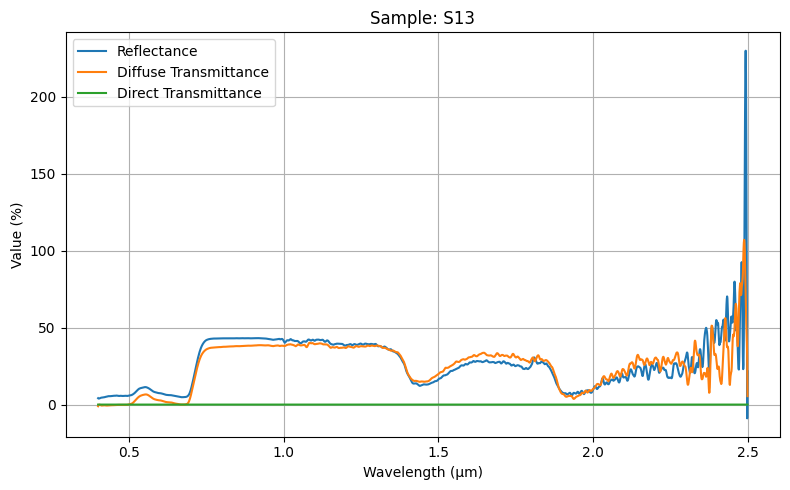

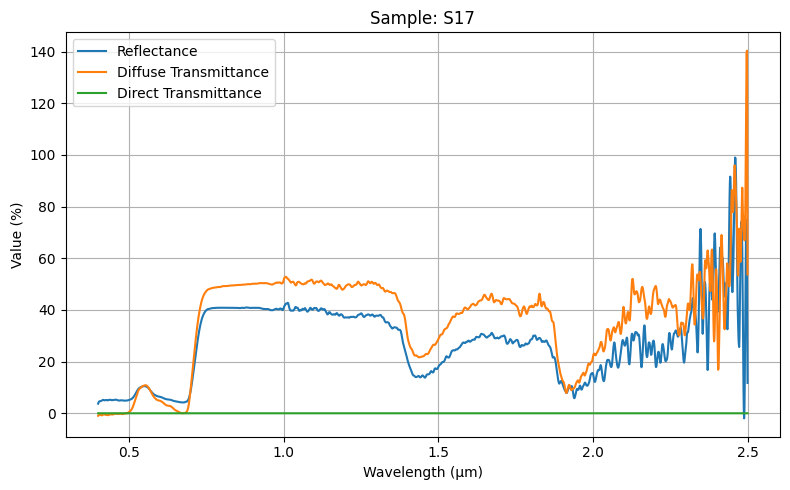

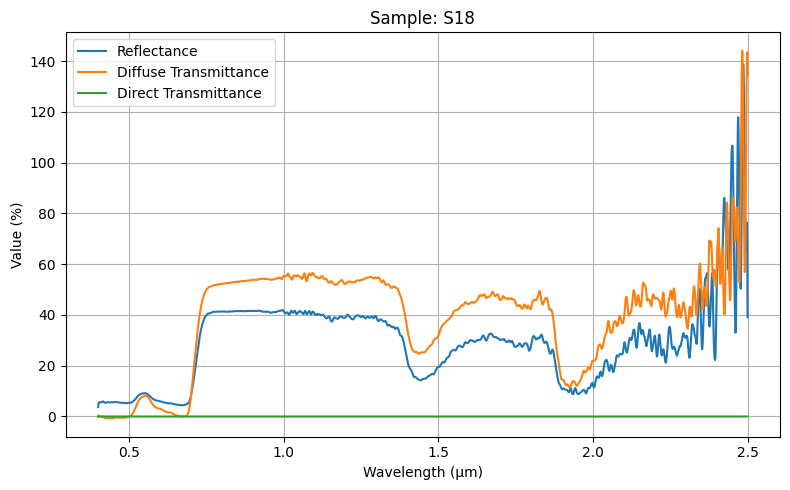

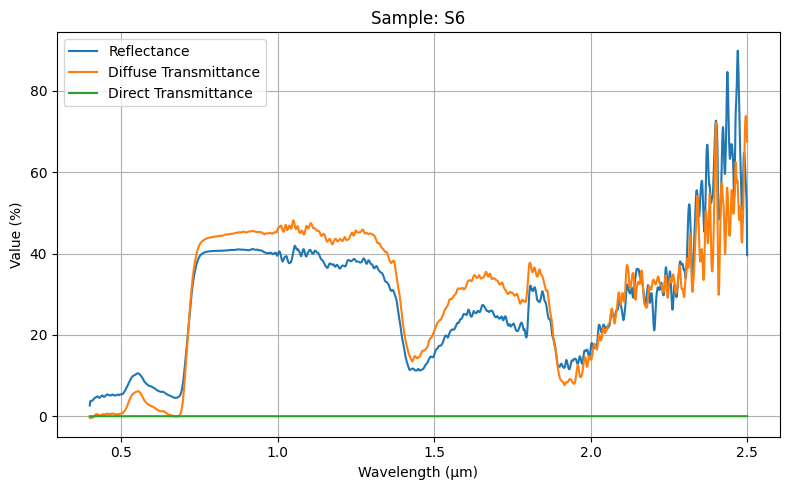

In [125]:
# Ordner mit den txt-Dateien
folder = Path("D:/Andreas/Databases/S10/Prosopis")

# Alle .txt Dateien durchgehen
for file in folder.glob("*.txt"):
    
    # Datei einlesen (ggf. sep anpassen)
    df = pd.read_csv(file, sep="\t")   # z.B. sep="," falls CSV-ähnlich
    
    # Sample-Name aus Dateiname
    sample = file.stem

    # Plot
    plt.figure(figsize=(8, 5))

    plt.plot(df["wavelength"], df["reflectance"], label="Reflectance")
    plt.plot(df["wavelength"], df["diffuse_transmittance"], label="Diffuse Transmittance")
    plt.plot(df["wavelength"], df["direct_transmittance"], label="Direct Transmittance")


    plt.xlabel("Wavelength (µm)")
    plt.ylabel("Value (%)")
    plt.title(f"Sample: {sample}")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Special Case Acacia


In [126]:
# Getting only the Good Samples for each Site and Acacias

#Site 3
samples_acacia_tortilis_s3 = ["S60"]#[
#    "S57", "S58", "S59", "S60",
#    "S61", "S62", "S63", "S64",
#    "S65", "S66", "S67", "S68",
#    "S69", "S70", "S71", "S72"
#]

#Site 20
samples_acacia_tortilis_s20 = [
    "S270", "S271", "S272", "S273",
    "S274", "S275", "S276", "S277",
    "S278", "S279", "S280", "S281",
    "S282", "S283", "S284", "S285"
]

samples_acacia_tortilis_s20 = [
    sample for sample in samples_acacia_tortilis_s20
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 10
samples_acacia_tortilis_s10 =  [
    "S19", "S20", "S21", "S22"
]

samples_acacia_tortilis_s10 = [
    sample for sample in samples_acacia_tortilis_s10
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 11
samples_acacia_tortilis_s11 =  [
    "S366",
    "S367",
    "S368",
    "S369",
    "S370",
    "S371",
    "S372",
    "S373",
    "S374",
    "S375",
    "S376",
    "S377"
]

samples_acacia_tortilis_s11 = [
    sample for sample in samples_acacia_tortilis_s11
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 14R
samples_acacia_tortilis_s14r = [
    "S157",
    "S158",
    "S159",
    "S160"
]

samples_acacia_tortilis_s14r = [
    sample for sample in samples_acacia_tortilis_s14r
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 18
samples_acacia_tortilis_s18 = [
    "S175", "S176", "S177", "S178",
    "S179", "S180", "S181", "S182",
    "S183", "S184", "S185", "S186",
    "S187", "S188", "S189", "S190"
]
samples_acacia_tortilis_s18 = [
    sample for sample in samples_acacia_tortilis_s18
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 21
samples_acacia_tortilis_s21 = [
    "S129", "S130", "S131", "S132",
    "S133", "S134", "S135", "S136",
    "S137", "S138", "S139"
]
samples_acacia_tortilis_s21 = [
    sample for sample in samples_acacia_tortilis_s21
    if sample in results_filtered_N_TT["Sample"].values
]

samples_acacia_karro_s21 = [
    "S140", "S141", "S142", "S143",
    "S144", "S145", "S146", "S147",
    "S148", "S149", "S150", "S151",
    "S152"
]

samples_acacia_karro_s21 = [
    sample for sample in samples_acacia_karro_s21
    if sample in results_filtered_N_TT["Sample"].values
]

samples_acacia_melifera_s21 = [
    "S153", "S154", "S155", "S156"
]

samples_acacia_melifera_s21 = [
    sample for sample in samples_acacia_melifera_s21
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 24
samples_acacia_tortilis_s24 = [
    "S23", "S24", "S25", "S26",
    "S27", "S28", "S29", "S30",
    "S31", "S32", "S33", "S34",
    "S35", "S36", "S37", "S38",
    "S39", "S40", "S41", "S42",
    "S43", "S44", "S45", "S46"
]
samples_acacia_tortilis_s24 = [
    sample for sample in samples_acacia_tortilis_s24
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 26
samples_acacia_tortilis_s26r = [
    "S262",
    "S263",
    "S264",
    "S265"
]
samples_acacia_tortilis_s26r = [
    sample for sample in samples_acacia_tortilis_s26r
    if sample in results_filtered_N_TT["Sample"].values
]

#Site 27
samples_acacia_tortilis_s27 = [
    "S300",
    "S301",
    "S302",
    "S303",
    "S304",
    "S305",
    "S306",
    "S307",
    "S308",
    "S309",
    "S310",
    "S311",
    "S312",
    "S313",
    "S314",
    "S315"
]

samples_acacia_tortilis_s27 = [
    sample for sample in samples_acacia_tortilis_s27
    if sample in results_filtered_N_TT["Sample"].values
]

In [127]:
samples_acacia = {

    "S3": {
        "Acacia_tortilis": samples_acacia_tortilis_s3
    },

    "S10": {
        "Acacia_tortilis": samples_acacia_tortilis_s10
    },

    "S11": {
        "Acacia_tortilis": samples_acacia_tortilis_s11
    },

    "S14R": {
        "Acacia_tortilis": samples_acacia_tortilis_s14r
    },

    "S18": {
        "Acacia_tortilis": samples_acacia_tortilis_s18
    },

    "S20": {
        "Acacia_tortilis": samples_acacia_tortilis_s20
    },

    "S21": {
        "Acacia_tortilis": samples_acacia_tortilis_s21,
        "Acacia_karro": samples_acacia_karro_s21,
        "Acacia_melifera": samples_acacia_melifera_s21
    },

    "S24": {
        "Acacia_tortilis": samples_acacia_tortilis_s24
    },

    "S26R": {
        "Acacia_tortilis": samples_acacia_tortilis_s26r
    },

    "S27": {
        "Acacia_tortilis": samples_acacia_tortilis_s27
    }
}

In [128]:
from matplotlib import pyplot as plt
# Reading the previously corrected reflectance and transmittance files
forward_reflectance = pd.read_csv("C:/Users/Andreas/Documents/Merged_Data/Forward_Reflectance.csv", sep=",")
forward_transmittance = pd.read_csv("C:/Users/Andreas/Documents/Merged_Data/Forward_Transmittance.csv", sep=",")

# Selecting Outputfolder
output_root = r"D:/Andreas/Databases"

for site, species_dict in samples_acacia.items():

    for species, sample_list in species_dict.items():

        output_folder = os.path.join(
            output_root,
            site,
            species
        )

        os.makedirs(output_folder, exist_ok=True)

        print(f"Processing {site} - {species}")
        print(f"Samples: {len(sample_list)}")
# Loop over every sample and editing the basefile, that for every sample the reflectance, direct_transmittance and diffuse_transmittance is formatted in the right way
        for sample in sample_list:

            df = base.copy()

            # Reflectance einsetzen
            df["reflectance"] = forward_reflectance[sample].values
            df["reflectance"] = df["reflectance"] * 100
            df["direct_transmittance"] = 0

            df["diffuse_transmittance"] = forward_transmittance[sample].values
            df["diffuse_transmittance"] = df["diffuse_transmittance"] * 100

            df.to_csv(
                os.path.join(output_folder, f"{sample}.txt"),
                sep="\t",
                index=False
            )




Processing S3 - Acacia_tortilis
Samples: 1
Processing S10 - Acacia_tortilis
Samples: 2
Processing S11 - Acacia_tortilis
Samples: 3
Processing S14R - Acacia_tortilis
Samples: 3
Processing S18 - Acacia_tortilis
Samples: 0
Processing S20 - Acacia_tortilis
Samples: 10
Processing S21 - Acacia_tortilis
Samples: 5
Processing S21 - Acacia_karro
Samples: 5
Processing S21 - Acacia_melifera
Samples: 4
Processing S24 - Acacia_tortilis
Samples: 4
Processing S26R - Acacia_tortilis
Samples: 0
Processing S27 - Acacia_tortilis
Samples: 7


# Ground Data

In [136]:
# Selecting Input and Output folder for Ground Data
input_folder = r"D:/Andreas/Databases/original_Ground_bark_data/unknown Site/Ground"
output_folder = r"D:/Andreas/Databases/unknown Site/Ground"

os.makedirs(output_folder, exist_ok=True)

# Looping over every file and editing base file in that way that the ground reflectances are in the right format for DART
for file in os.listdir(input_folder):

    if file.endswith(".txt"):

        # Ground-Datei einlesen
        ground = pd.read_csv(
            os.path.join(input_folder, file),
            sep="\t"
        )

        # Wellenlänge umrechnen
        ground["wavelength"] = ground["Wavelength(nm)"] / 1000

        # nur >= 0.400 µm
        ground_400 = ground[ground["wavelength"] >= 0.400]

        # base kopieren
        df = base.copy()

        # Reflectance über Wellenlänge einsetzen
        reflectance_values = ground_400.set_index("wavelength")["Reflectance"]

        df["reflectance"] = df["wavelength"].map(reflectance_values) * 100

        # Transmittance = 0, because it was not measured
        df["direct_transmittance"] = 0
        df["diffuse_transmittance"] = 0

        # Dateiname übernehmen
        sample = os.path.splitext(file)[0]

        df.to_csv(
            os.path.join(output_folder, f"{sample}.txt"),
            sep="\t",
            index=False
        )

# Bark Data

In [139]:
# Selecting Input and Output folder for Bark Data

input_folder = r"D:/Andreas/Databases/original_Ground_bark_data/S25R/Prosopis_Bark"
output_folder = r"D:/Andreas/Databases/S25R/Prosopis_Bark"

os.makedirs(output_folder, exist_ok=True)

# Looping over every file and editing base file in that way that the ground reflectances are in the right format for DART

for file in os.listdir(input_folder):

    if file.endswith(".txt"):

        # Ground-Datei einlesen
        bark = pd.read_csv(
            os.path.join(input_folder, file),
            sep="\t"
        )

        # Wellenlänge umrechnen
        bark["wavelength"] = bark["Wavelength(nm)"] / 1000

        # nur >= 0.400 µm
        bark_400 = bark[bark["wavelength"] >= 0.400]

        # base kopieren
        df = base.copy()

        # Reflectance über Wellenlänge einsetzen
        reflectance_values = bark_400.set_index("wavelength")["Reflectance"]

        df["reflectance"] = df["wavelength"].map(reflectance_values) * 100

        # Transmittance auf 0 setzen
        df["direct_transmittance"] = 0
        df["diffuse_transmittance"] = 0

        # Dateiname übernehmen
        sample = os.path.splitext(file)[0]

        df.to_csv(
            os.path.join(output_folder, f"{sample}.txt"),
            sep="\t",
            index=False
        )

In [ ]:
from matplotlib import pyplot as plt

# Assumes `df` from the user's code is available in the notebook.
plt.figure(figsize=(8,4.5))
plt.plot(df["wavelength"], df["reflectance"], label="Reflectance")
plt.plot(df["wavelength"], df["diffuse_transmittance"], label="Diffuse Transmittance")
plt.xlabel("Wavelength (µm)")
plt.ylabel("Value")
plt.title("Last sample")
plt.legend()
plt.grid(True)

out="/mnt/data/last_sample_plot.png"
plt.tight_layout()
plt.savefig(out)
plt.close()

print(out)

In [3]:
import json

root = Path(r"D:/Andreas/Databases")

pv_names = {
    "acacia_tortilis",
    "acacia_karro",
    "acacia_melifera",
    "prosopis",
    "ficus",
    "parthenium",
    "balanite_aegyptica",
    "Fruticosa",
    "Acacia",
    "Papyrus",
    "Acacia_Melifera",
    "fruticosa",
    "papyrus",
    "acacia",
    "acacia_melifera"
}

npv_names = {
    "prosopis_bark",
    "ficus_bark"
}

rows = []

for txt in root.glob("*/*/*.txt"):
    site = txt.parts[-3]
    folder2 = txt.parts[-2]
    sample_id = txt.stem
    key = folder2.lower()

    if key in pv_names:
        category = "PV"
    elif key in npv_names:
        category = "NPV"
    elif key == "Ground":
        category = "Soil"
    else:
        category = folder2

    df = pd.read_csv(txt, sep=r"\s+|,|\t", engine="python")
    df.columns = [c.lower().strip() for c in df.columns]

    if "wavelength" not in df.columns or "reflectance" not in df.columns:
        continue

    x = pd.to_numeric(df["wavelength"], errors="coerce")
    y = pd.to_numeric(df["reflectance"], errors="coerce") / 100.0
    valid = x.notna() & y.notna()

    profiles = {
        "x": x[valid].tolist(),
        "y": y[valid].tolist(),
        "xUnit": "μm",
        "yUnit": "reflectance"
    }

    rows.append({
        "site": site,
        "category": category,
        "species": folder2,
        "sample_id": sample_id,
        "profiles": json.dumps(profiles)
    })

out = pd.DataFrame(rows)
out.to_csv("enmapbox_spectral_library_table.csv", index=False)

In [ ]:
"""
Resample high-resolution field spectra (e.g. ASD) to EnMAP spectral resolution
using Gaussian spectral response function (SRF) convolution.

Each EnMAP band is treated as a Gaussian centered at its band center wavelength,
with width derived from its FWHM. The resampled reflectance at that band is the
FWHM-weighted average of your source reflectance values.
"""

from collections import OrderedDict
import numpy as np
import pandas as pd
import glob
import os

# --- EnMAP band centers and FWHM ---------------------------------------
responses = OrderedDict()
wavelength = [460, 465, 470, 475, 479, 484, 489, 494, 499, 503, 508, 513, 518, 523, 528, 533, 538, 543, 549,
              554, 559, 565, 570, 575, 581, 587, 592, 598, 604, 610, 616, 622, 628, 634, 640, 646, 653, 659,
              665, 672, 679, 685, 692, 699, 706, 713, 720, 727, 734, 741, 749, 756, 763, 771, 778, 786, 793,
              801, 809, 817, 824, 832, 840, 848, 856, 864, 872, 880, 888, 896, 915, 924, 934, 944, 955, 965,
              975, 986, 997, 1007, 1018, 1029, 1040, 1051, 1063, 1074, 1086, 1097, 1109, 1120, 1132, 1144, 1155,
              1167, 1179, 1191, 1203, 1215, 1227, 1239, 1251, 1263, 1275, 1287, 1299, 1311, 1323, 1522, 1534,
              1545, 1557, 1568, 1579, 1590, 1601, 1612, 1624, 1634, 1645, 1656, 1667, 1678, 1689, 1699, 1710,
              1721, 1731, 1742, 1752, 1763, 1773, 1783, 2044, 2053, 2062, 2071, 2080, 2089, 2098, 2107, 2115,
              2124, 2133, 2141, 2150, 2159, 2167, 2176, 2184, 2193, 2201, 2210, 2218, 2226, 2234, 2243, 2251,
              2259, 2267, 2275, 2283, 2292, 2300, 2308, 2315, 2323, 2331, 2339, 2347, 2355, 2363, 2370, 2378,
              2386, 2393, 2401, 2409]
fwhm = [5.8, 5.8, 5.8, 5.8, 5.8, 5.8, 5.8, 5.8, 5.8, 5.8, 5.9, 5.9, 6.0, 6.0, 6.1, 6.1, 6.2, 6.2, 6.3, 6.4, 6.4,
        6.5, 6.6, 6.6, 6.7, 6.8, 6.9, 6.9, 7.0, 7.1, 7.2, 7.3, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 7.9, 8.0, 8.1,
        8.2, 8.3, 8.4, 8.4, 8.5, 8.6, 8.7, 8.7, 8.8, 8.9, 8.9, 9.0, 9.1, 9.1, 9.2, 9.3, 9.3, 9.4, 9.4, 9.5, 9.5,
        9.6, 9.6, 9.6, 9.6, 9.7, 9.7, 9.7, 11.8, 11.9, 12.1, 12.2, 12.4, 12.5, 12.7, 12.8, 12.9, 13.1, 13.2,
        13.3, 13.4, 13.5, 13.6, 13.7, 13.8, 13.9, 14.0, 14.0, 14.1, 14.1, 14.2, 14.2, 14.3, 14.3, 14.3, 14.4,
        14.4, 14.4, 14.4, 14.4, 14.4, 14.4, 14.4, 14.4, 14.4, 13.7, 13.6, 13.6, 13.5, 13.5, 13.4, 13.4, 13.3,
        13.2, 13.2, 13.1, 13.1, 13.0, 12.9, 12.9, 12.8, 12.8, 12.7, 12.7, 12.6, 12.5, 12.5, 12.4, 12.4, 12.3,
        10.9, 10.8, 10.8, 10.7, 10.7, 10.6, 10.6, 10.5, 10.5, 10.4, 10.4, 10.4, 10.3, 10.3, 10.2, 10.2, 10.1,
        10.1, 10.1, 10.0, 10.0, 9.9, 9.9, 9.9, 9.8, 9.8, 9.7, 9.7, 9.7, 9.6, 9.6, 9.6, 9.5, 9.5, 9.4, 9.4, 9.4,
        9.3, 9.3, 9.3, 9.2, 9.2, 9.1, 9.1, 9.1]
for w, f in zip(wavelength, fwhm):
    responses[w] = f


def gaussian_srf(center, fwhm, wavelengths):
    """Gaussian spectral response function for one EnMAP band."""
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    return np.exp(-0.5 * ((wavelengths - center) / sigma) ** 2)


def resample_spectrum(src_wl, src_refl, responses, min_coverage=0.5):
    """
    Resample one spectrum (src_wl, src_refl) onto the EnMAP band centers in `responses`.

    min_coverage: if the fraction of usable (non-NaN) weight under a band's Gaussian
    falls below this, the output for that band is NaN instead of a biased average.
    Guards against gaps in your source data (e.g. instrument noise regions) silently
    skewing the resampled value.
    """
    src_wl = np.asarray(src_wl, dtype=float)
    src_refl = np.asarray(src_refl, dtype=float)
    valid = ~np.isnan(src_refl)

    out = np.empty(len(responses))
    for i, (center, fwhm) in enumerate(responses.items()):
        w = gaussian_srf(center, fwhm, src_wl)
        w_valid = w * valid
        total_w = w.sum()
        valid_w = w_valid.sum()
        if total_w == 0 or (valid_w / total_w) < min_coverage:
            out[i] = np.nan
        else:
            out[i] = np.sum(w_valid * np.nan_to_num(src_refl)) / valid_w
    return out


def build_library_from_folder(folder, wavelength_col="wavelength", reflectance_col="reflectance"):
    """
    Loop over one CSV per sample in `folder`, resample each to EnMAP bands,
    and return a DataFrame ready to export for the spectral library.
    Assumes the class label / sample metadata is encoded in the filename or
    tracked separately -- adjust the `name` extraction to your naming scheme.
    """
    target_wavelengths = list(responses.keys())
    rows = []
    for path in sorted(glob.glob(os.path.join(folder, "*.csv"))):
        name = os.path.splitext(os.path.basename(path))[0]
        s = pd.read_csv(path).sort_values(wavelength_col)
        resampled = resample_spectrum(s[wavelength_col].values, s[reflectance_col].values, responses)
        row = {"name": name}
        row.update({f"b{i+1}_{wl}nm": val for i, (wl, val) in enumerate(zip(target_wavelengths, resampled))})
        rows.append(row)
    return pd.DataFrame(rows)


if __name__ == "__main__":
    # Example usage:
    # library_df = build_library_from_folder("spectra/")
    # library_df.to_csv("resampled_library.csv", index=False)
    pass